# FWI vs. Key Climate Drivers — GFDL-ESM4 (Thailand)

**Analysis:** Annual area-weighted Fire Weather Index (FWI) against four climate drivers
(maximum temperature, precipitation, surface wind speed, and relative humidity)
for Thailand (5.5°–20.5°N, 97.5°–105.5°E) across historical and five SSP scenarios.

**Model:** GFDL-ESM4 | **Source:** CMIP6  
**FWI dataset:** Dobrynin et al. (2021) pre-computed annual FWI (0.25° grid)  
**Driver datasets:** CMIP6 monthly atmospheric variables (1°×1° grid)  

> **Reproducibility note:** Set `DATA_ROOT` in Section 1 to the root folder that
> contains the `FWICMIP6/`, `tasmax/`, `pr/`, `sfcWind/`, and `hurs/` sub-directories.


## 1  Dependencies

In [1]:
# Standard library
from pathlib import Path

# Third-party
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy.stats import linregress


## 2  Configuration

Edit `DATA_ROOT` to match your local data directory, then run all cells.


In [3]:
# ── User configuration ───────────────────────────────────────────────────────
DATA_ROOT = Path("/Volumes/jubjang/Jubjang")   # <-- change this if needed

OUTPUT_FILE = "FWI_vs_4drivers_Thailand_2x2.png"

# Study region: Thailand
TH_SLICE = dict(lat=slice(5.5, 20.5), lon=slice(97.5, 105.5))

# Scenario identifiers
SCENARIOS = ["historical", "ssp119", "ssp126", "ssp245", "ssp370", "ssp585"]

# Display labels (used in legend)
SCENARIO_LABELS = {
    "historical": "Historical",
    "ssp119":     "SSP1-1.9",
    "ssp126":     "SSP1-2.6",
    "ssp245":     "SSP2-4.5",
    "ssp370":     "SSP3-7.0",
    "ssp585":     "SSP5-8.5",
}

# Colour-blind-friendly palette (Wong, 2011)
PALETTE = {
    "historical": "#000000",
    "ssp119":     "#E69F00",
    "ssp126":     "#56B4E9",
    "ssp245":     "#009E73",
    "ssp370":     "#882255",
    "ssp585":     "#CC79A7",
}


## 3  Load datasets

All variables are loaded lazily with `xarray.open_mfdataset`; actual data are
read on demand during the analysis step.

| Variable | Units (raw) | Grid |
|---|---|---|
| `fwisa` | dimensionless | 0.25° × 0.25° (annual) |
| `tasmax` | K | ~1° × 1° (monthly) |
| `pr` | kg m⁻² s⁻¹ | ~1° × 1° (monthly) |
| `sfcWind` | m s⁻¹ | ~1° × 1° (monthly) |
| `hurs` | % | ~1° × 1° (monthly) |


In [5]:
def _open(path_pattern):
    """
    Open one or more NetCDF files as a single dataset.

    Accepts a single Path/string (with or without ``*`` glob),
    or a list of Paths/strings.  Glob patterns are expanded with
    ``sorted()`` so the time axis is always in chronological order.
    """
    import glob as _glob

    patterns = path_pattern if isinstance(path_pattern, list) else [path_pattern]

    resolved = []
    for p in patterns:
        p_str = str(p)
        if "*" in p_str or "?" in p_str:
            matched = sorted(_glob.glob(p_str))
            if not matched:
                raise FileNotFoundError(
                    f"No files matched the pattern: {p_str}"
                )
            resolved.extend(matched)
        else:
            resolved.append(p_str)

    return xr.open_mfdataset(
        resolved,
        combine="by_coords",
        engine="netcdf4",
    )


# ── FWI (annual, 0.25° grid) ─────────────────────────────────────────────────
FWI_DIR = DATA_ROOT / "FWICMIP6"

fwi_files = {
    "historical": FWI_DIR / "fwisa_ann_GFDL-ESM4_historical_r1i1p1f1_g025.nc",
    "ssp119":     FWI_DIR / "fwisa_ann_GFDL-ESM4_ssp119_r1i1p1f1_g025.nc",
    "ssp126":     FWI_DIR / "fwisa_ann_GFDL-ESM4_ssp126_r1i1p1f1_g025.nc",
    "ssp245":     FWI_DIR / "fwisa_ann_GFDL-ESM4_ssp245_r1i1p1f1_g025.nc",
    "ssp370":     FWI_DIR / "fwisa_ann_GFDL-ESM4_ssp370_r1i1p1f1_g025.nc",
    "ssp585":     FWI_DIR / "fwisa_ann_GFDL-ESM4_ssp585_r1i1p1f1_g025.nc",
}

# ── tasmax (monthly, ~1° grid) ───────────────────────────────────────────────
TAS_DIR = DATA_ROOT / "tasmax"

tasmax_files = {
    "historical": [
        TAS_DIR / "tasmax_Amon_GFDL-ESM4_historical_r1i1p1f1_gr1_185001-194912.nc",
        TAS_DIR / "tasmax_Amon_GFDL-ESM4_historical_r1i1p1f1_gr1_195001-201412.nc",
    ],
    "ssp119": TAS_DIR / "tasmax_Amon_GFDL-ESM4_ssp119_r1i1p1f1_gr1_201501-210012.nc",
    "ssp126": TAS_DIR / "tasmax_Amon_GFDL-ESM4_ssp126_r1i1p1f1_gr1_*.nc",
    "ssp245": TAS_DIR / "tasmax_Amon_GFDL-ESM4_ssp245_r1i1p1f1_gr1_*.nc",
    "ssp370": TAS_DIR / "tasmax_Amon_GFDL-ESM4_ssp370_r1i1p1f1_gr1_*.nc",
    "ssp585": TAS_DIR / "tasmax_Amon_GFDL-ESM4_ssp585_r1i1p1f1_gr1_*.nc",
}

# ── pr (monthly, ~1° grid) ───────────────────────────────────────────────────
PR_DIR = DATA_ROOT / "pr"

pr_files = {
    "historical": [
        PR_DIR / "pr_Amon_GFDL-ESM4_historical_r1i1p1f1_gr1_185001-194912.nc",
        PR_DIR / "pr_Amon_GFDL-ESM4_historical_r1i1p1f1_gr1_195001-201412.nc",
    ],
    "ssp119": PR_DIR / "pr_Amon_GFDL-ESM4_ssp119_r1i1p1f1_gr1_*.nc",
    "ssp126": PR_DIR / "pr_Amon_GFDL-ESM4_ssp126_r1i1p1f1_gr1_*.nc",
    "ssp245": PR_DIR / "pr_Amon_GFDL-ESM4_ssp245_r1i1p1f1_gr1_*.nc",
    "ssp370": PR_DIR / "pr_Amon_GFDL-ESM4_ssp370_r1i1p1f1_gr1_*.nc",
    "ssp585": PR_DIR / "pr_Amon_GFDL-ESM4_ssp585_r1i1p1f1_gr1_*.nc",
}

# ── sfcWind (monthly, ~1° grid) ──────────────────────────────────────────────
WIND_DIR = DATA_ROOT / "sfcWind"

sfcwind_files = {
    "historical": [
        WIND_DIR / "sfcWind_Amon_GFDL-ESM4_historical_r1i1p1f1_gr1_185001-194912.nc",
        WIND_DIR / "sfcWind_Amon_GFDL-ESM4_historical_r1i1p1f1_gr1_195001-201412.nc",
    ],
    "ssp119": WIND_DIR / "sfcWind_Amon_GFDL-ESM4_ssp119_r1i1p1f1_gr1_*.nc",
    "ssp126": WIND_DIR / "sfcWind_Amon_GFDL-ESM4_ssp126_r1i1p1f1_gr1_*.nc",
    "ssp245": WIND_DIR / "sfcWind_Amon_GFDL-ESM4_ssp245_r1i1p1f1_gr1_*.nc",
    "ssp370": WIND_DIR / "sfcWind_Amon_GFDL-ESM4_ssp370_r1i1p1f1_gr1_*.nc",
    "ssp585": WIND_DIR / "sfcWind_Amon_GFDL-ESM4_ssp585_r1i1p1f1_gr1_*.nc",
}

# ── hurs (monthly, ~1° grid) ─────────────────────────────────────────────────
HURS_DIR = DATA_ROOT / "hurs"

hurs_files = {
    "historical": [
        HURS_DIR / "hurs_Amon_GFDL-ESM4_historical_r1i1p1f1_gr1_185001-194912.nc",
        HURS_DIR / "hurs_Amon_GFDL-ESM4_historical_r1i1p1f1_gr1_195001-201412.nc",
    ],
    "ssp119": HURS_DIR / "hurs_Amon_GFDL-ESM4_ssp119_r1i1p1f1_gr1_*.nc",
    "ssp126": HURS_DIR / "hurs_Amon_GFDL-ESM4_ssp126_r1i1p1f1_gr1_*.nc",
    "ssp245": HURS_DIR / "hurs_Amon_GFDL-ESM4_ssp245_r1i1p1f1_gr1_*.nc",
    "ssp370": HURS_DIR / "hurs_Amon_GFDL-ESM4_ssp370_r1i1p1f1_gr1_*.nc",
    "ssp585": HURS_DIR / "hurs_Amon_GFDL-ESM4_ssp585_r1i1p1f1_gr1_*.nc",
}

# ── Open all datasets ─────────────────────────────────────────────────────────
ds_fwi    = {s: _open(fwi_files[s])     for s in SCENARIOS}
ds_tasmax = {s: _open(tasmax_files[s])  for s in SCENARIOS}
ds_pr     = {s: _open(pr_files[s])      for s in SCENARIOS}
ds_wind   = {s: _open(sfcwind_files[s]) for s in SCENARIOS}
ds_hurs   = {s: _open(hurs_files[s])    for s in SCENARIOS}

print("All datasets opened successfully.")


All datasets opened successfully.


## 4  Compute grid-cell area weights

Grid-cell areas are derived analytically from the spherical Earth formula:

$$A_i = R^2 \, \Delta\lambda \, \bigl(\sin\phi_2 - \sin\phi_1\bigr)$$

where $R$ is the Earth's mean radius, $\Delta\lambda$ the longitude spacing,
and $\phi_1, \phi_2$ the latitude bounds of each cell.

Two area grids are constructed because the FWI and driver variables live on
different horizontal resolutions:

| Grid | Shape | Used for |
|---|---|---|
| `areacella` | 72 × 144 | FWI (0.25° native, regridded to 2.5°) |
| `areacella_tas` | 180 × 288 | tasmax / pr / sfcWind / hurs |


In [7]:
def _compute_areacella(lat_coords: np.ndarray, lon_coords: np.ndarray) -> xr.Dataset:
    """
    Return an xr.Dataset with variable ``area`` (km²) on the supplied lat/lon grid.

    Parameters
    ----------
    lat_coords : 1-D array of latitude centres (degrees)
    lon_coords : 1-D array of longitude centres (degrees)
    """
    R = 6_378_137.0  # WGS-84 mean radius (m)

    lat_rad = np.radians(lat_coords)
    lon_rad = np.radians(lon_coords)
    d_lon   = np.diff(lon_rad).mean()
    d_lat   = np.diff(lat_rad).mean()

    area = np.zeros((len(lat_rad), len(lon_rad)))
    for i, phi in enumerate(lat_rad):
        phi1 = phi - d_lat / 2
        phi2 = phi + d_lat / 2
        area[i, :] = R**2 * d_lon * (np.sin(phi2) - np.sin(phi1))

    area_km2 = area / 1e6  # convert m² → km²

    return xr.Dataset({
        "area": xr.DataArray(
            area_km2, dims=["lat", "lon"],
            coords={"lat": lat_coords, "lon": lon_coords},
            attrs={"units": "km2", "long_name": "grid-cell area"},
        )
    })


# FWI grid  (72 lat × 144 lon)
areacella = _compute_areacella(
    lat_coords=np.linspace(-88.75,  88.75,  72),
    lon_coords=np.linspace(  1.25, 358.75, 144),
)

# Driver grid  (180 lat × 288 lon)
areacella_tas = _compute_areacella(
    lat_coords=np.linspace(-89.5,  89.5,  180),
    lon_coords=np.linspace(0.625, 359.375, 288),
)

print("areacella      →", areacella)
print("areacella_tas  →", areacella_tas)


areacella      → <xarray.Dataset>
Dimensions:  (lat: 72, lon: 144)
Coordinates:
  * lat      (lat) float64 -88.75 -86.25 -83.75 -81.25 ... 83.75 86.25 88.75
  * lon      (lon) float64 1.25 3.75 6.25 8.75 11.25 ... 351.2 353.8 356.2 358.8
Data variables:
    area     (lat, lon) float64 1.689e+03 1.689e+03 ... 1.689e+03 1.689e+03
areacella_tas  → <xarray.Dataset>
Dimensions:  (lat: 180, lon: 288)
Coordinates:
  * lat      (lat) float64 -89.5 -88.5 -87.5 -86.5 -85.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 0.625 1.875 3.125 4.375 ... 355.6 356.9 358.1 359.4
Data variables:
    area     (lat, lon) float64 135.2 135.2 135.2 135.2 ... 135.2 135.2 135.2


## 5  Analysis helper functions


In [11]:
def _drop_time_dim(da: xr.Dataset) -> xr.Dataset:
    """Remove the time dimension from an area Dataset if present (e.g. after loading)."""
    if "time" in da.dims:
        da = da.isel(time=0)
        da = da.drop_vars([v for v in da.coords if "time" in v], errors="ignore")
    return da


def _annual_mean(ds: xr.Dataset) -> xr.Dataset:
    """Resample monthly data to annual means (calendar-year end)."""
    return ds.resample(time="YS").mean()


def _area_weighted_mean(da: xr.DataArray, weights: xr.Dataset,
                        region: dict) -> xr.DataArray:
    """
    Return the area-weighted spatial mean of *da* over *region*.

    Parameters
    ----------
    da      : DataArray to average (must have lat/lon dims)
    weights : Dataset with an ``area`` variable on a compatible grid
    region  : dict of slice kwargs, e.g. ``dict(lat=slice(5.5, 20.5), lon=slice(97.5, 105.5))``
    """
    w = (
        weights
        .sel(lat=da.lat, lon=da.lon, method="nearest")
        .sel(**region)["area"]
    )
    return da.sel(**region).weighted(w).mean(dim=["lat", "lon"])


## 6  Plotting function

`plot_fwi_vs_4vars_grid` produces a 2 × 2 panel figure showing area-weighted
annual FWI against each of the four climate drivers for all scenarios.
A linear regression line is overlaid on each scatter cloud.


In [13]:
def plot_fwi_vs_4vars_grid(
    ds_fwi:    dict,
    ds_tasmax: dict,
    ds_pr:     dict,
    ds_wind:   dict,
    ds_hurs:   dict,
    scenarios: list,
    labels:    dict,
    palette:   dict,
    area_fwi:  xr.Dataset,
    area_drv:  xr.Dataset,
    region:    dict = TH_SLICE,
    filename:  str  = OUTPUT_FILE,
) -> None:
    """
    2 × 2 scatter plot: annual area-weighted FWI vs. four climate drivers.

    Parameters
    ----------
    ds_fwi, ds_tasmax, ds_pr, ds_wind, ds_hurs
        Dicts keyed by scenario string containing xarray Datasets.
    scenarios : list of scenario keys (order determines plotting order)
    labels    : dict mapping scenario key → legend label
    palette   : dict mapping scenario key → hex colour
    area_fwi  : areacella Dataset for the FWI grid
    area_drv  : areacella Dataset for the driver grids
    region    : lat/lon slice dict defining the study region
    filename  : output filename (PNG, 300 dpi)
    """
    # ── Pre-process area grids ────────────────────────────────────────────────
    area_fwi = _drop_time_dim(area_fwi)
    area_drv = _drop_time_dim(area_drv)

    # ── Panel definitions ─────────────────────────────────────────────────────
    panels = [
        dict(key="tasmax",  ds=ds_tasmax, xlabel="Maximum Temperature (°C)",   label="a)"),
        dict(key="pr",      ds=ds_pr,     xlabel="Precipitation (mm day⁻¹)",   label="b)"),
        dict(key="sfcWind", ds=ds_wind,   xlabel="Surface Wind Speed (m s⁻¹)", label="c)"),
        dict(key="hurs",    ds=ds_hurs,   xlabel="Relative Humidity (%)",       label="(d)"),
    ]

    fig, axes = plt.subplots(
        2, 2, figsize=(5.51, 4.3),
        constrained_layout=True, sharey="row",
    )
    axes = axes.flatten()
    legend_handles = {}

    for ax, panel in zip(axes, panels):
        var = panel["key"]
        ax.set_title(panel["label"], loc="left", fontsize=13)

        for scen in scenarios:
            # ── Slice to region ───────────────────────────────────────────────
            fwi_reg = ds_fwi[scen].sel(**region)
            drv_reg = panel["ds"][scen].sel(**region)

            # ── Resample driver to annual, align with FWI time axis ───────────
            drv_ann = _annual_mean(drv_reg).sel(
                time=fwi_reg["time"], method="nearest"
            )

            # ── Area-weighted spatial means ───────────────────────────────────
            fwi_mean = _area_weighted_mean(fwi_reg["fwisa"], area_fwi, region)

            if var == "tasmax":
                x_mean = (
                    _area_weighted_mean(drv_ann["tasmax"], area_drv, region)
                    - 273.15                    # K → °C
                )
            elif var == "pr":
                x_mean = (
                    _area_weighted_mean(drv_ann["pr"], area_drv, region)
                    * 86_400.0                  # kg m⁻² s⁻¹ → mm day⁻¹
                )
            elif var == "sfcWind":
                x_mean = _area_weighted_mean(drv_ann["sfcWind"], area_drv, region)
            elif var == "hurs":
                x_mean = _area_weighted_mean(drv_ann["hurs"],    area_drv, region)
            else:
                continue

            x_vals = np.asarray(x_mean.values)
            y_vals = np.asarray(fwi_mean.values)

            if x_vals.size == 0 or x_vals.size != y_vals.size:
                continue

            color = palette.get(scen, "#000000")
            sc = ax.scatter(x_vals, y_vals, s=5, alpha=0.6, color=color)

            # ── Linear regression overlay ─────────────────────────────────────
            slope, intercept, *_ = linregress(x_vals, y_vals)
            x_fit = np.linspace(x_vals.min(), x_vals.max(), 100)
            ax.plot(x_fit, slope * x_fit + intercept, "-", lw=1.5, color=color)

            lbl = labels.get(scen, scen)
            if lbl not in legend_handles:
                legend_handles[lbl] = sc

        ax.set_xlabel(panel["xlabel"], fontsize=11)
        ax.set_ylim(0, 50)
        ax.grid(True, linestyle="solid", alpha=0.6)
        ax.tick_params(labelsize=10)

    # ── Y-axis labels (left column only) ─────────────────────────────────────
    for idx, ax in enumerate(axes):
        if idx % 2 == 0:
            ax.set_ylabel("FWI", fontsize=13)
        else:
            ax.set_ylabel(None)
            ax.tick_params(labelleft=False)

    # ── Shared legend ─────────────────────────────────────────────────────────
    fig.legend(
        legend_handles.values(),
        legend_handles.keys(),
        loc="upper center",
        bbox_to_anchor=(0.5, 0.01),
        ncol=3, frameon=False, fontsize=10,
    )

    fig.savefig(filename, dpi=300, bbox_inches="tight")
    print(f"Figure saved → {filename}")
    plt.show()


## 7  Generate figure

Figure saved → FWI_vs_4drivers_Thailand_2x2.png


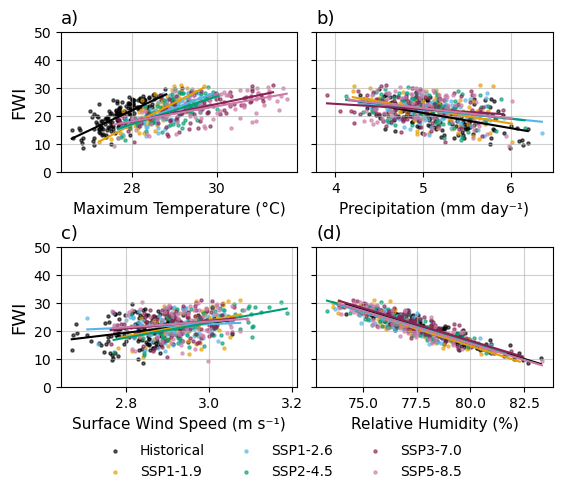

In [15]:
plot_fwi_vs_4vars_grid(
    ds_fwi    = ds_fwi,
    ds_tasmax = ds_tasmax,
    ds_pr     = ds_pr,
    ds_wind   = ds_wind,
    ds_hurs   = ds_hurs,
    scenarios = SCENARIOS,
    labels    = SCENARIO_LABELS,
    palette   = PALETTE,
    area_fwi  = areacella,
    area_drv  = areacella_tas,
    region    = TH_SLICE,
    filename  = OUTPUT_FILE,
)
